In [1]:
# Name: Herve Tepongning Megnifo
# Program: Business Intelligence Analysis
# Course: Introduction to Mathematics for Machine Learning
# Assignment 15: Loan Default Prediction


In [2]:
# Introduction
#This assignment aims to test your ability to analyze business problems, preprocess data, build machine learning models, and evaluate them for performance and fairness. You will apply the skills learned in the lab to predict loan default and recommend actions based on your findings.

In [3]:
# Task 1: Python code for loading and cleaning the dataset.

In [4]:
# Import dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import joblib
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Load dataset from a public URL and read it into a pandas DataFrame
# url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv'
# columns = ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree', 'age', 'outcome']
data = pd.read_csv("bank-loan.csv")

# Check columns
print(data.columns)

Index(['age', 'ed', 'employ', 'address', 'income', 'debtinc', 'creddebt',
       'othdebt', 'default'],
      dtype='str')


In [6]:
print(data.head())
print(data.dtypes)

   age  ed  employ  address  income  debtinc   creddebt   othdebt  default
0   41   3      17       12     176      9.3  11.359392  5.008608      1.0
1   27   1      10        6      31     17.3   1.362202  4.000798      0.0
2   40   1      15       14      55      5.5   0.856075  2.168925      0.0
3   41   1      15       14     120      2.9   2.658720  0.821280      0.0
4   24   2       2        0      28     17.3   1.787436  3.056564      1.0
age           int64
ed            int64
employ        int64
address       int64
income        int64
debtinc     float64
creddebt    float64
othdebt     float64
default     float64
dtype: object


In [7]:
# Data exploration
print(data.info())

print()
print(data.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 59.9 KB
None

age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     150
dtype: int64


In [8]:
"""
The default attribute contains 150 missing values in the dataset. Since this is a case study, 
we will impute these missing values using the mode of the default attribute. 
"""

'\nThe default attribute contains 150 missing values in the dataset. Since this is a case study, \nwe will impute these missing values using the mode of the default attribute. \n'

In [9]:
data['default'].value_counts()

default
0.0    517
1.0    183
Name: count, dtype: int64

In [10]:
"""
The dependent variable default is imbalanced, with 517 observations for non-default (0) and only 183 observations for default (1). 
Therefore, we will address the class imbalance using a resampling technique such as SMOTE to improve accuracy.
"""

'\nThe dependent variable default is imbalanced, with 517 observations for non-default (0) and only 183 observations for default (1). \nTherefore, we will address the class imbalance using a resampling technique such as SMOTE to improve accuracy.\n'

In [11]:
# Assign the mode value in the dependent variable

data['default'] = data['default'].fillna(data['default'].mode()[0])
print(data.isnull().sum())

age         0
ed          0
employ      0
address     0
income      0
debtinc     0
creddebt    0
othdebt     0
default     0
dtype: int64


In [12]:
# Verification
data['default'].value_counts()

default
0.0    667
1.0    183
Name: count, dtype: int64

In [13]:
"""
In this study, demographic variables such as age and gender 
are potentially sensitive attributes for the fairness analysis

Let’s take a look at their distribution to better understand their representation
"""

'\nIn this study, demographic variables such as age and gender \nare potentially sensitive attributes for the fairness analysis\n\nLet’s take a look at their distribution to better understand their representation\n'

In [14]:
data['age'].describe()

count    850.000000
mean      35.029412
std        8.041432
min       20.000000
25%       29.000000
50%       34.000000
75%       41.000000
max       56.000000
Name: age, dtype: float64

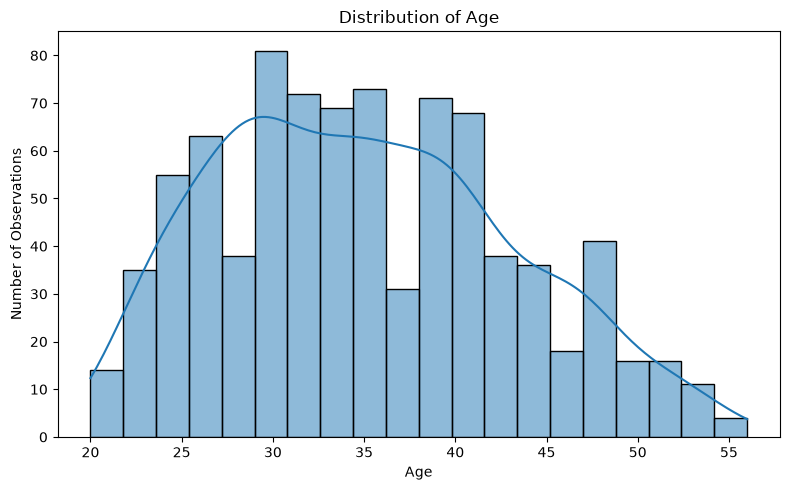

In [15]:
# Age distribution
import seaborn as sns
plt.figure(figsize=(8, 5))

sns.histplot(data['age'], bins=20, kde=True)

plt.xlabel('Age')
plt.ylabel('Number of Observations')
plt.title('Distribution of Age')
plt.tight_layout()
plt.show()

In [16]:
# Sensitive feature encoding (using 'age' as a proxy for fairness)
sensitive_feature = pd.cut(data['age'], bins=[20, 30, 40, 50, 60, 100], labels=['20-30', '30-40', '40-50', '50-60', '60+'])


In [17]:
# Select features and dependent variable
X = data.drop(columns=['default'])

# Target encoding
y = data['default']

In [18]:
# Split data with stratification

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
# Apply SMOTE to the training data
# Check the dependent variable before applying Smote
print("Before SMOTE:")
print(y_train.value_counts())


Before SMOTE:
default
0.0    534
1.0    146
Name: count, dtype: int64


In [20]:
# Apply SMOTE to the training data
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [21]:
# Check the result
print("\nAfter SMOTE:")
print(y_train.value_counts())


After SMOTE:
default
0.0    534
1.0    534
Name: count, dtype: int64


In [22]:
# Train Logistic Regression Model
# Initialize a logistic regression model with 1000 iterations for convergence
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Performance Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7470588235294118
Confusion Matrix:
 [[98 35]
 [ 8 29]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.92      0.74      0.82       133
         1.0       0.45      0.78      0.57        37

    accuracy                           0.75       170
   macro avg       0.69      0.76      0.70       170
weighted avg       0.82      0.75      0.77       170



       accuracy  selection_rate  false_positive_rate  true_positive_rate
age                                                                     
20-30  0.627451        0.686275             0.542857            1.000000
30-40  0.793651        0.253968             0.185185            0.666667
40-50  0.784314        0.215686             0.146341            0.500000
50-60  1.000000        0.400000             0.000000            1.000000


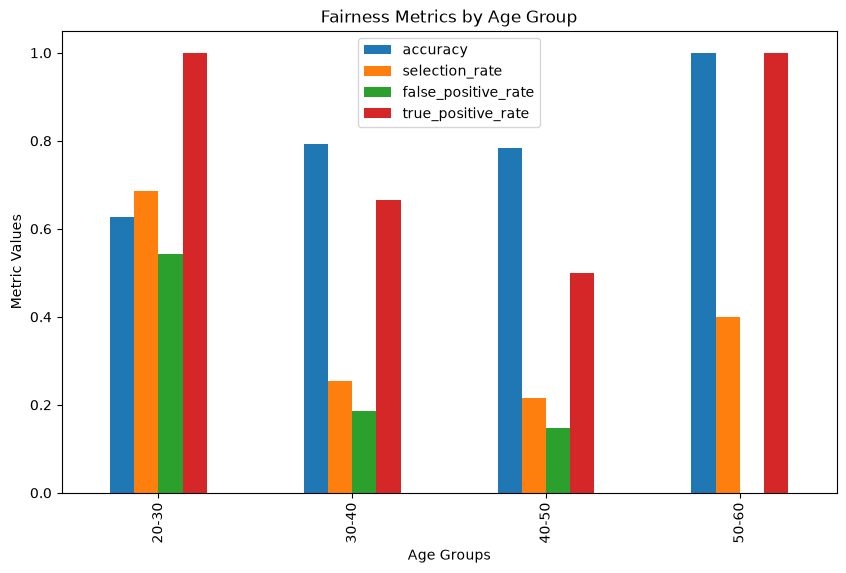

In [23]:
# 3. Fairness Analysis using Fairlearn
# Create a MetricFrame to compute fairness metrics by group
metric_frame = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'selection_rate': selection_rate,
        'false_positive_rate': false_positive_rate,
        'true_positive_rate': true_positive_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_feature[X_test.index]
)
print(metric_frame.by_group)
metric_frame.by_group.plot(kind='bar', figsize=(10, 6))
plt.title("Fairness Metrics by Age Group")
plt.ylabel("Metric Values")
plt.xlabel("Age Groups")
plt.show()

In [24]:
'''
The fairness analysis shows noticeable differences in model performance across age groups. 
The 20–30 age group has the highest selection rate and false-positive rate, while the 40–50 age group has the lowest selection rate and a lower false-positive rate. 
The 50–60 age group shows perfect accuracy and a 100% true-positive rate.

'''

'\nThe fairness analysis shows noticeable differences in model performance across age groups. \nThe 20–30 age group has the highest selection rate and false-positive rate, while the 40–50 age group has the lowest selection rate and a lower false-positive rate. \nThe 50–60 age group shows perfect accuracy and a 100% true-positive rate.\n\n'

Background dataset has 170 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=170 when initializing the masker.
ExactExplainer explainer: 171it [00:16, 10.30it/s]                         


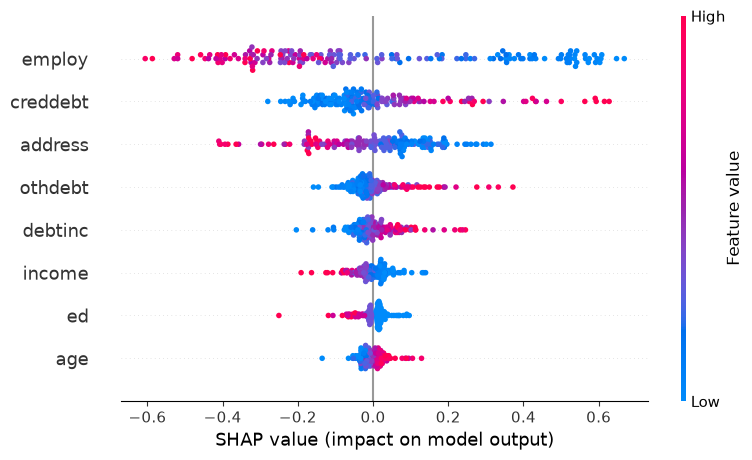

In [25]:

# 4. Explainability Analysis
# SHAP Analysis
explainer = shap.Explainer(model.predict, X_test)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

In [26]:
'''
Some attributes are associated with a higher likelihood of default (1), particularly othdebt, debtinc, age, and creddebt. 
In contrast, employ, address, income, and ed appear to be associated with a higher likelihood of non-default (0).
'''


'\nSome attributes are associated with a higher likelihood of default (1), particularly othdebt, debtinc, age, and creddebt. \nIn contrast, employ, address, income, and ed appear to be associated with a higher likelihood of non-default (0).\n'

In [27]:
# LIME Analysis
import lime
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

# Create the LIME explainer
explainer = LimeTabularExplainer(
    training_data=X_train.to_numpy(),
    feature_names=X_train.columns.tolist(),
    class_names=['No Default', 'Default'],
    mode='classification'
)



In [32]:
sample = X_test.iloc[0].to_numpy()

exp = explainer.explain_instance(
    sample,
    model.predict_proba,
    num_features=len(X_test.columns)
)

for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

employ > 11.00: -0.4945
0.40 < creddebt <= 0.99: -0.1300
address <= 2.00: 0.1224
income > 49.00: -0.0877
ed <= 1.00: 0.0657
debtinc <= 5.94: -0.0584
27.00 < age <= 32.00: -0.0232
1.99 < othdebt <= 4.05: -0.0100


In [30]:
# Insight
'''
For this individual, employment history was the strongest factor, with more than 11 years of employment strongly pushing the model's prediction away from default. 
In addition, credit-card debt and income also pushed it away from default. 

However, a short period at the current address pushed the prediction toward default.
'''

"\nFor this individual, employment history was the strongest factor, with more than 11 years of employment strongly pushing the model's prediction away from default. \nIn addition, credit-card debt and income also pushed it away from default. \n\nHowever, a short period at the current address pushed the prediction toward default.\n"

In [33]:
sample = X_test.iloc[20].to_numpy()

exp = explainer.explain_instance(
    sample,
    model.predict_proba,
    num_features=len(X_test.columns)
)

for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

creddebt > 1.97: 0.3444
2.00 < employ <= 5.00: 0.1648
address <= 2.00: 0.1286
debtinc > 16.10: 0.1003
1.00 < ed <= 2.00: -0.0317
age <= 27.00: -0.0232
22.00 < income <= 32.00: 0.0180
1.99 < othdebt <= 4.05: -0.0057


In [ ]:
'''
For observation 20, credit-card debt above 1.97 (0.34) was the strongest factor pushing the model toward default, 
followed by a short employment history (0.16), short residential history (0.12), and a debt-to-income ratio above 16.1 (0.1).

'''

In [31]:
# 5. Save Model
joblib.dump(model, 'fairness_model_v1.pkl')


['fairness_model_v1.pkl']